In [3]:
%pip install torch torch-geometric scikit-learn networkx pandas seaborn matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.datasets import Planetoid

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
dataset = Planetoid(root='data/Planetoid', name='Cora')

Processing...
Done!


In [4]:
data = dataset[0]

print(f"Numbers of paper (Nodes) :{data.num_nodes}")
print(f"Numbers of Citations (Edges) : {data.num_edges}")
print(f"features per paper : {data.num_node_features}")
print(f"Numbers of topics : {dataset.num_classes}")
print(f"training paper : {data.train_mask.sum()}")
print(f"validation paper : {data.val_mask.sum()}")
print(f"test paper : {data.test_mask.sum()}")

Numbers of paper (Nodes) :2708
Numbers of Citations (Edges) : 10556
features per paper : 1433
Numbers of topics : 7
training paper : 140
validation paper : 500
test paper : 1000


<Axes: xlabel='None', ylabel='count'>

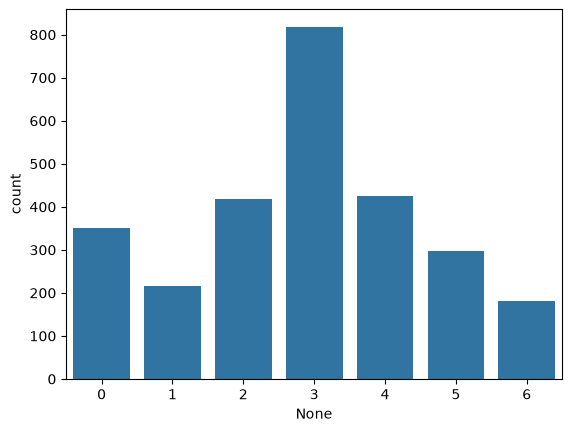

In [5]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

sns.barplot(x = topic_counts.index, y = topic_counts)

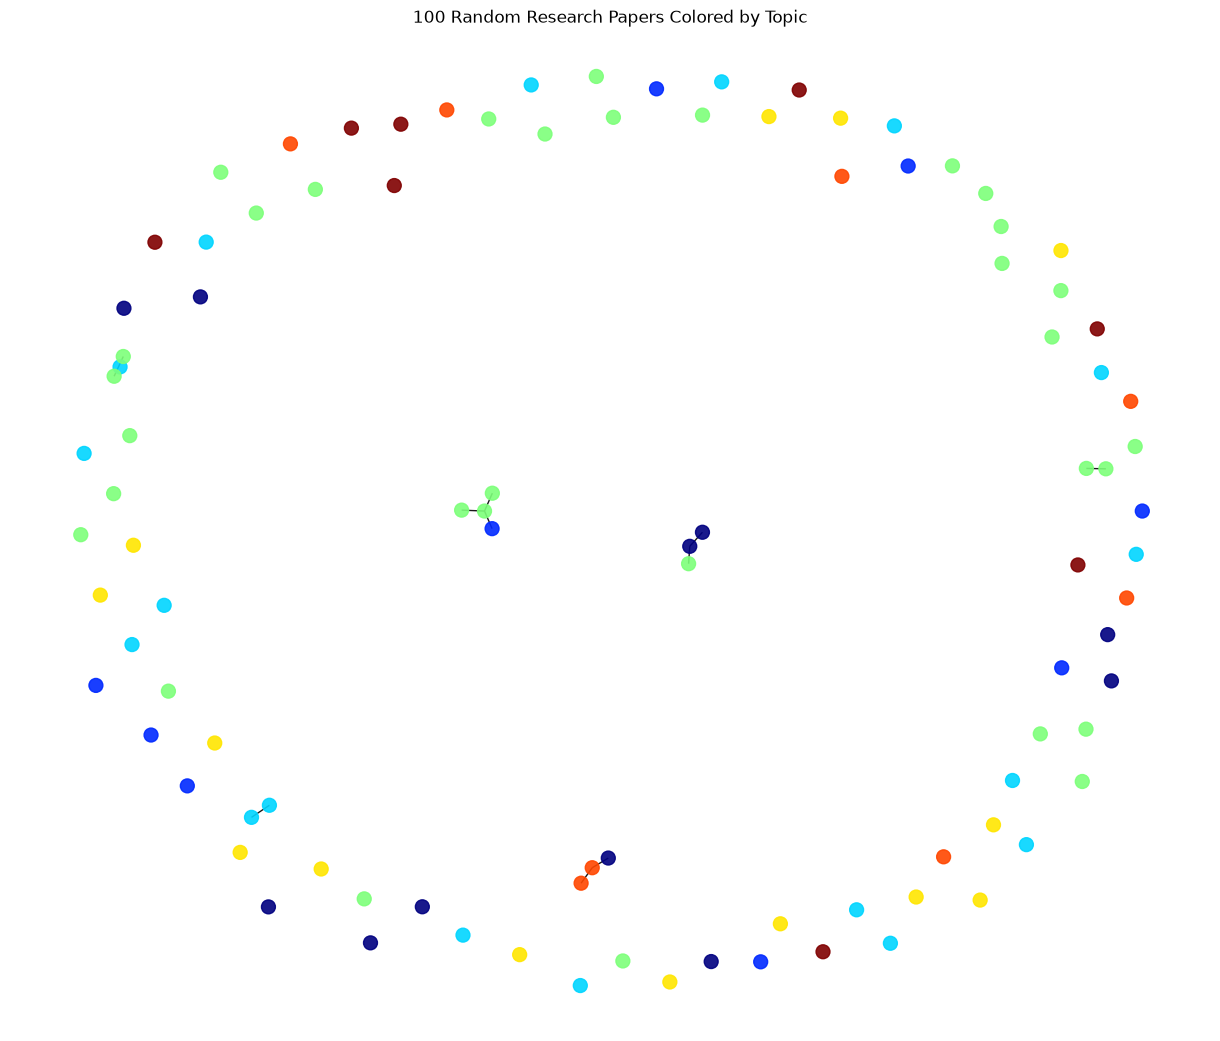

In [6]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

In [7]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [8]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [9]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer() # reweight karta hai [when the features occur in 0 and 1 and now they will come in weighted features like 0.22 by the help of {Tfidf}]
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.nonzero()
val_idx = data.val_mask.nonzero()
test_idx = data.test_mask.nonzero()

X_train, y_train = X_baseline[train_idx].squeeze(), y[train_idx]
X_test,y_test = X_baseline[test_idx].squeeze(), y[test_idx]
# X_val = X_baseline[val_idx]

rf = RandomForestClassifier(n_estimators=100, max_features = 'sqrt',class_weight = 'balanced',random_state = 42,n_jobs = -1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
# print("X_baseline shape:", X_baseline.shape)
# print("X_train shape:", X_train.shape)

In [10]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
rf_acc = accuracy_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred,average = 'macro')
print(f"Accuracy : {accuracy_score(y_test,rf_pred):.4f}")
print(f"Macro-f1 : {f1_score(y_test,rf_pred,average = 'macro'):.4f}")

Accuracy : 0.5810
Macro-f1 : 0.5698


<Axes: >

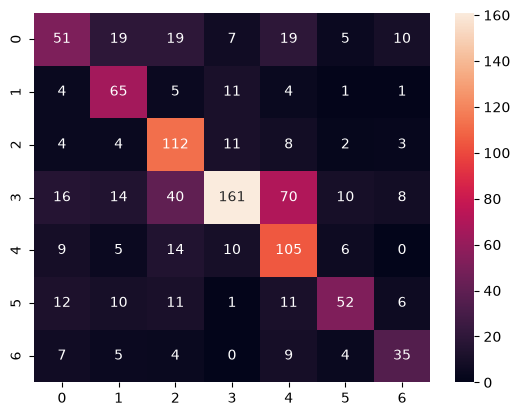

In [11]:
sns.heatmap(confusion_matrix(y_test,rf_pred),annot = True,fmt = 'd')

In [12]:
from torch import nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch
class SimpleGCN(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim,dropout = 0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim, output_dim)
    self.dropout = dropout

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = F.relu(x)
    x = F.dropout(x,p = self.dropout,training = self.training)
    x = self.conv2(x,edge_index)
    return x
model = SimpleGCN(input_dim = data.num_features,hidden_dim = 32,output_dim = dataset.num_classes)
optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)


In [13]:
import torch.nn.functional as F

# Training of GCN MODEL
def train_one_epoch():
  model.train()
  optimizer.zero_grad()
  logits = model(data.x,data.edge_index)
  loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss.item()

@torch.no_grad()
def evaluate(mask):
  model.eval()
  logits = model(data.x,data.edge_index)
  predictions = logits[mask].argmax(dim = 1)
  # Corrected line: predictions is already masked, so compare directly with masked data.y
  accuracy = (predictions == data.y[mask]).float().mean().item()
  # Corrected line: predictions is already masked, and .numpy() is a method
  macro_f1 = f1_score(data.y[mask].numpy(),predictions.numpy(),average = 'macro')
  return accuracy,macro_f1,predictions

In [14]:
losses , train_accuracies, val_accuracies = [],[],[]
best_val_accuracy = 0.0
best_state = None

epoch_without_imporvement = 0
patience = 20

for epoch in range(1,201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy)

  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_state = model.state_dict()
    epoch_without_imporvement = 0
  else:
    epoch_without_imporvement += 1

  if epoch_without_imporvement >= patience:
    print(f"Early stopping {epoch}")
    break

  if epoch == 1 or epoch % 10 ==0:
    print(f"Epoch : {epoch:03d}, Loss : {loss:.4f}, Train Accuracy : {train_accuracy:.4f}, Val Accuracy : {val_accuracy:.4f}")

    model.load_state_dict(best_state)
    gcn_accuracy,gcn_f1,gcn_pred = evaluate(data.test_mask)
print(f"GCN Test Accuracy : {gcn_accuracy:.4f}, GCN Test macro_F1 : {gcn_f1:.4f}")

Epoch : 001, Loss : 1.9616, Train Accuracy : 0.6429, Val Accuracy : 0.3780
Epoch : 010, Loss : 0.5193, Train Accuracy : 0.9857, Val Accuracy : 0.7820
Epoch : 020, Loss : 0.0772, Train Accuracy : 1.0000, Val Accuracy : 0.7780
Epoch : 030, Loss : 0.0331, Train Accuracy : 1.0000, Val Accuracy : 0.7840
Early stopping 31
GCN Test Accuracy : 0.8010, GCN Test macro_F1 : 0.7936


<Axes: >

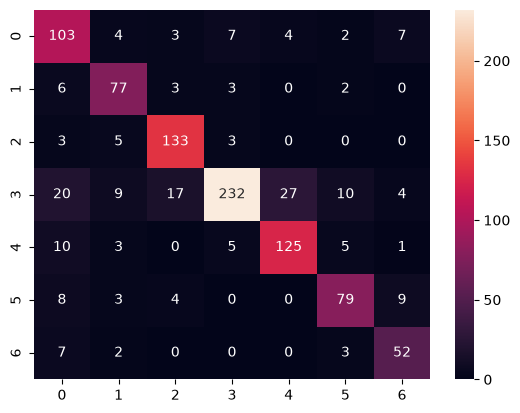

In [15]:
sns.heatmap(confusion_matrix(data.y[data.test_mask].numpy(),gcn_pred.numpy()),annot = True,fmt = 'd')

In [16]:
results  = pd.DataFrame({
    'Model' : ['Random Forest','GCN'],
    'Accuracy' : [rf_acc,gcn_accuracy],
    'Macro-F1' : [rf_f1,gcn_f1]

})
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.581,0.569807
1,GCN,0.801,0.793622


In [17]:
import torch
%pip install onnxscript
# set the model to evaluation
model.eval()

# create dummmy input for onnx export
# the input 'x' has shape [num_nodes,num_features]
# the input 'edge_index' has shape [2,edge_index]

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = 'simple_gcn_cora.onnx'

torch.onnx.export(
    model,                             #1. trained model
    (x_dummy, edge_index_dummy),       #2. model input
    onnx_file_path,                    #3. where to save the onnx model
    export_params = True,             #4. Store the trained parameter weights inside the model file
    opset_version = 18,                 #5. Change opset_version to 18 to avoid version conversation issue.
    do_constant_folding = True,         #6. whether to execute constant folding for optimization
    input_names = ['node_features','edge_indices'],  #7. input names
    output_names = ['logits'],   #8. output names
    dynamic_axes = {
        'node_features': {0: 'num_nodes'},    #9. var len for num_nodes
        'edge_indices' : {1: 'num_edges'}   # #10. var len for num_edge
    }
)

print(f'Model Exportes to {onnx_file_path}')


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached onnxscript-0.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached onnx_ir-1.0.0-py3-none-any.whl.metadata (3.3 kB)
Using cached onnxscript-0.7.2-py3-none-any.whl (754 kB)
Using cached onnx_ir-1.0.0-py3-none-any.whl (185 kB)
   ---------------------------------------- 0.0/7.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.9 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/7.9 MB 3.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/7.9 MB 3.0 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/7.9 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/7.9 MB 3.0 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/7.9 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/7.9 MB 2.9 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/7.9 MB 2.5 MB/s eta 0:00:02
   ------------

W0926 21:54:13.006000 2564 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0926 21:54:13.019000 2564 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0926 21:54:13.023000 2564 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W0926 21:54:13.025000 2564 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model Exportes to simple_gcn_cora.onnx
